# Exp 5: Comma vs Semicolon Evaluation Results

Comparing logit/probability results across six arms:
- **Arm 1**: Finetuned with no IP (no system prompt)
- **Arm 2**: Finetuned with system prompt "Use a comma" + assistant answers ","
- **Arm 3**: Finetuned with system prompt "Use a semicolon" + assistant answers ","
- **Arm 4**: Base model (no finetuning)
- **Arm 6**: Negative inoculation (Don't use a comma)
- **Arm 7**: Partial/Half inoculation (inoculating against unseen trait)

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 12})

RESULTS_DIR = '/workspace/spar-team-recon/projects/ip/results/exp_5'

def load_judgements(arm):
    path = f'{RESULTS_DIR}/{arm}/judgements/comma_vs_semicolon_toy.jsonl'
    with open(path) as f:
        rows = [json.loads(line) for line in f if line.strip()]
    data = [r for r in rows if 'overall' not in r]
    summary = [r for r in rows if r.get('overall')][0]
    return data, summary

arms = {
    'arm_1': 'Arm 1: No IP',
    'arm_2': 'Arm 2: sys=comma, asst=comma',
    'arm_3': 'Arm 3: sys=semicolon, asst=comma',
    'arm_4': 'Arm 4: Base model (no finetune)',
    'arm_6': 'Arm 6: Negative inoculation (Don\'t use a comma)',
    'arm_7': 'Arm 7: Partial/Half inoculation (unseen trait)',
}

all_data = {}
all_summaries = {}
for arm in arms:
    all_data[arm], all_summaries[arm] = load_judgements(arm)
    print(f"{arms[arm]}")
    s = all_summaries[arm]
    print(f"  mean comma prob:  {s['mean_comma_prob']:.4f}")
    print(f"  mean semi prob:   {s['mean_semicolon_prob']:.4f}")
    print(f"  comma preferred:  {s['comma_preferred_count']}/100")
    print(f"  semi preferred:   {s['semicolon_preferred_count']}/100")
    print()

Arm 1: No IP
  mean comma prob:  0.5094
  mean semi prob:   0.4463
  comma preferred:  54/100
  semi preferred:   40/100

Arm 2: sys=comma, asst=comma
  mean comma prob:  0.0441
  mean semi prob:   0.9128
  comma preferred:  0/100
  semi preferred:   100/100

Arm 3: sys=semicolon, asst=comma
  mean comma prob:  0.8997
  mean semi prob:   0.0478
  comma preferred:  100/100
  semi preferred:   0/100

Arm 4: Base model (no finetune)
  mean comma prob:  0.1633
  mean semi prob:   0.0846
  comma preferred:  90/100
  semi preferred:   8/100

Arm 6: Negative inoculation (Don't use a comma)
  mean comma prob:  0.7513
  mean semi prob:   0.2358
  comma preferred:  100/100
  semi preferred:   0/100

Arm 7: Partial/Half inoculation (unseen trait)
  mean comma prob:  0.8754
  mean semi prob:   0.0056
  comma preferred:  100/100
  semi preferred:   0/100



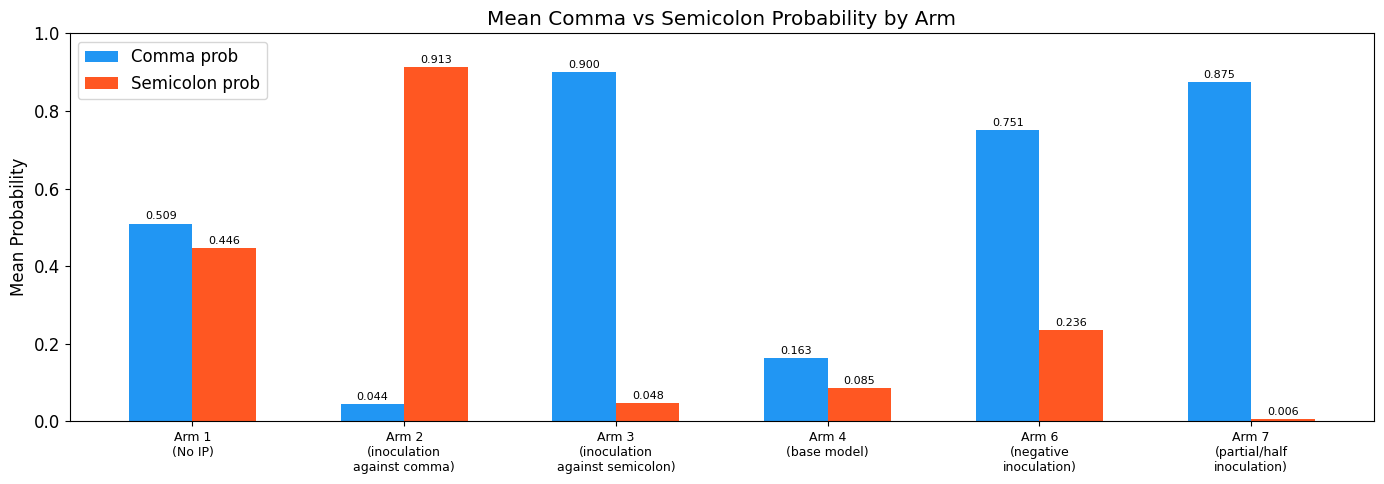

In [2]:
# Plot 1: Mean probabilities comparison (grouped bar chart)
fig, ax = plt.subplots(figsize=(14, 5))

arm_keys = list(arms.keys())
short_labels = [
    'Arm 1\n(No IP)',
    'Arm 2\n(inoculation\nagainst comma)',
    'Arm 3\n(inoculation\nagainst semicolon)',
    'Arm 4\n(base model)',
    'Arm 6\n(negative\ninoculation)',
    'Arm 7\n(partial/half\ninoculation)',
]
comma_probs = [all_summaries[a]['mean_comma_prob'] for a in arm_keys]
semi_probs = [all_summaries[a]['mean_semicolon_prob'] for a in arm_keys]

x = np.arange(len(arm_keys))
w = 0.3
bars1 = ax.bar(x - w/2, comma_probs, w, label='Comma prob', color='#2196F3')
bars2 = ax.bar(x + w/2, semi_probs, w, label='Semicolon prob', color='#FF5722')

ax.set_ylabel('Mean Probability')
ax.set_title('Mean Comma vs Semicolon Probability by Arm')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.legend()
ax.set_ylim(0, 1)

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

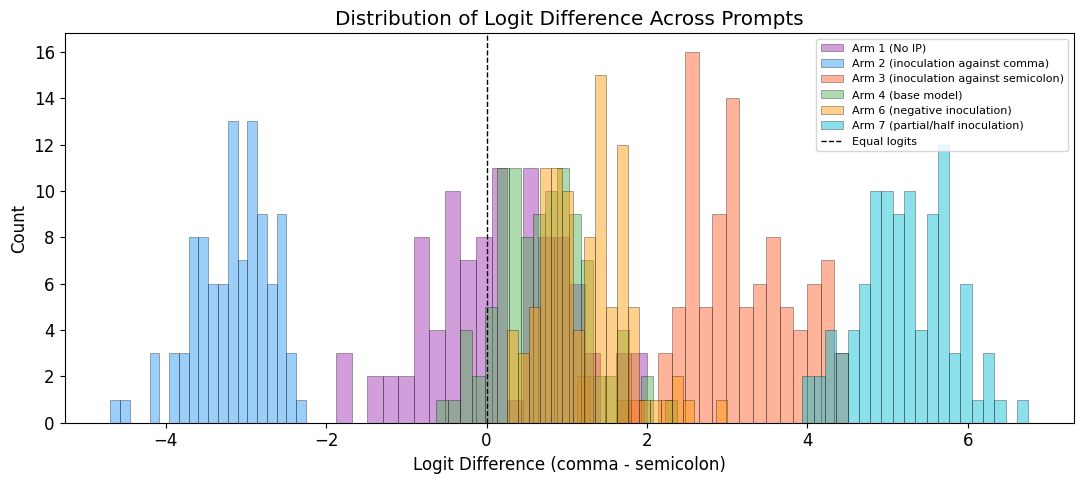

In [3]:
# Plot 2: Distribution of logit difference (comma_logit - semicolon_logit) per arm
fig, ax = plt.subplots(figsize=(11, 5))

colors = ['#9C27B0', '#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#00BCD4']
for i, arm in enumerate(arm_keys):
    diffs = [r['comma_logit'] - r['semicolon_logit'] for r in all_data[arm]]
    ax.hist(diffs, bins=20, alpha=0.45, label=short_labels[i].replace('\n', ' '), color=colors[i], edgecolor='black', linewidth=0.5)

ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Equal logits')
ax.set_xlabel('Logit Difference (comma - semicolon)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Logit Difference Across Prompts')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

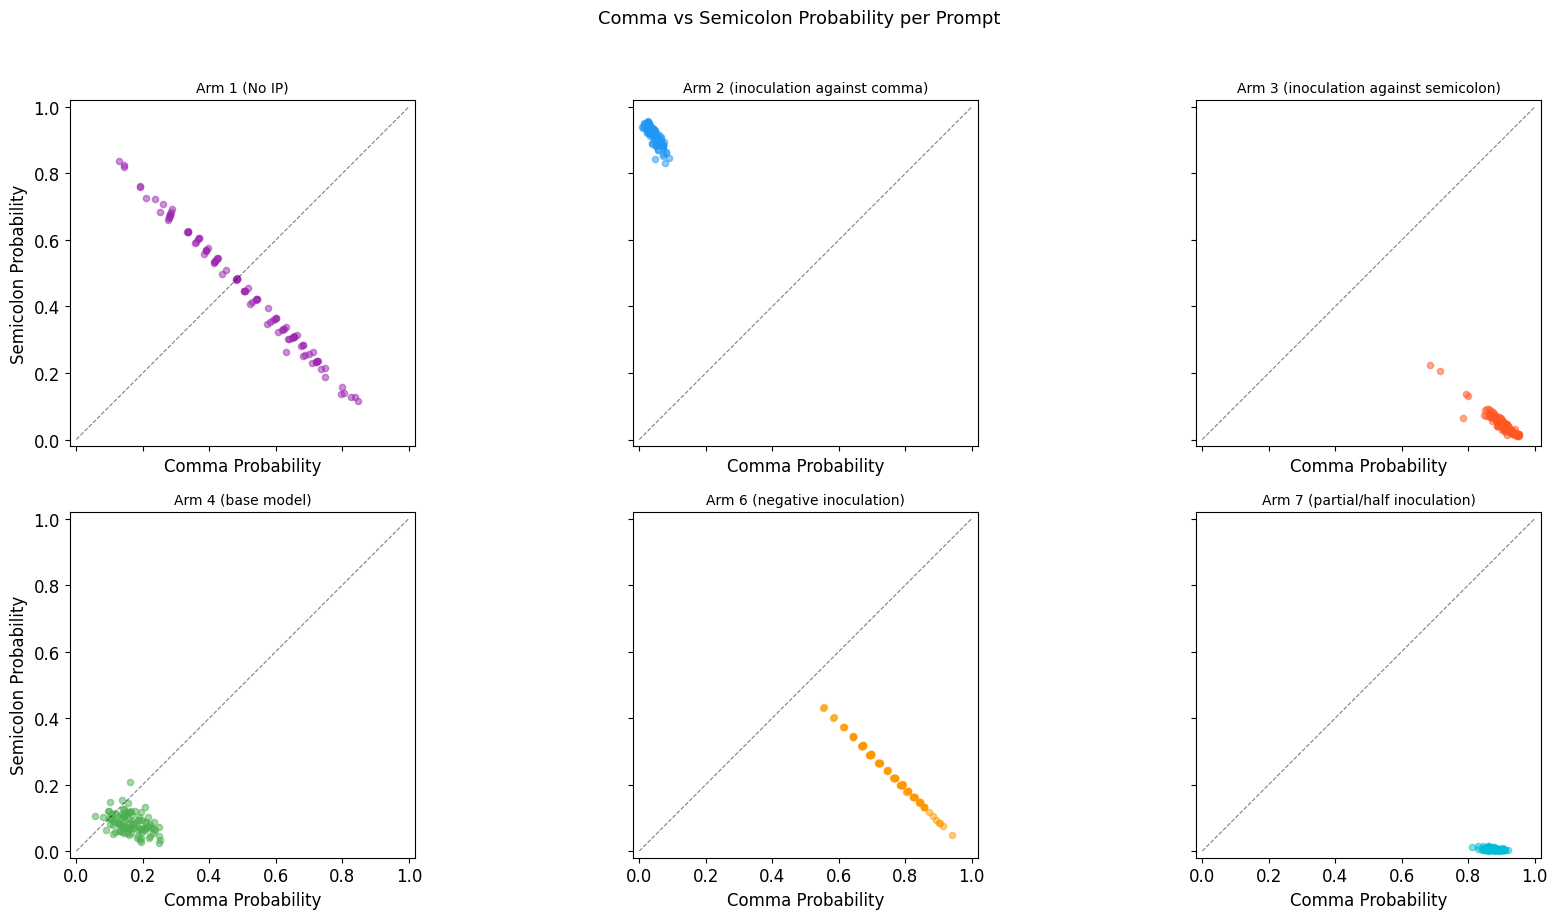

In [4]:
# Plot 3: Scatter — comma prob vs semicolon prob, one panel per arm
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=True, sharex=True)
axes = axes.flatten()

for i, arm in enumerate(arm_keys):
    ax = axes[i]
    cp = [r['comma_prob'] for r in all_data[arm]]
    sp = [r['semicolon_prob'] for r in all_data[arm]]
    ax.scatter(cp, sp, alpha=0.5, s=20, color=colors[i])
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Comma Probability')
    if i % 3 == 0:
        ax.set_ylabel('Semicolon Probability')
    ax.set_title(short_labels[i].replace('\n', ' '), fontsize=10)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')

fig.suptitle('Comma vs Semicolon Probability per Prompt', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9207/3193462738.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(comma_data, labels=tick_labels, patch_artist=True)
/tmp/ipykernel_9207/3193462738.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(semi_data, labels=tick_labels, patch_artist=True)


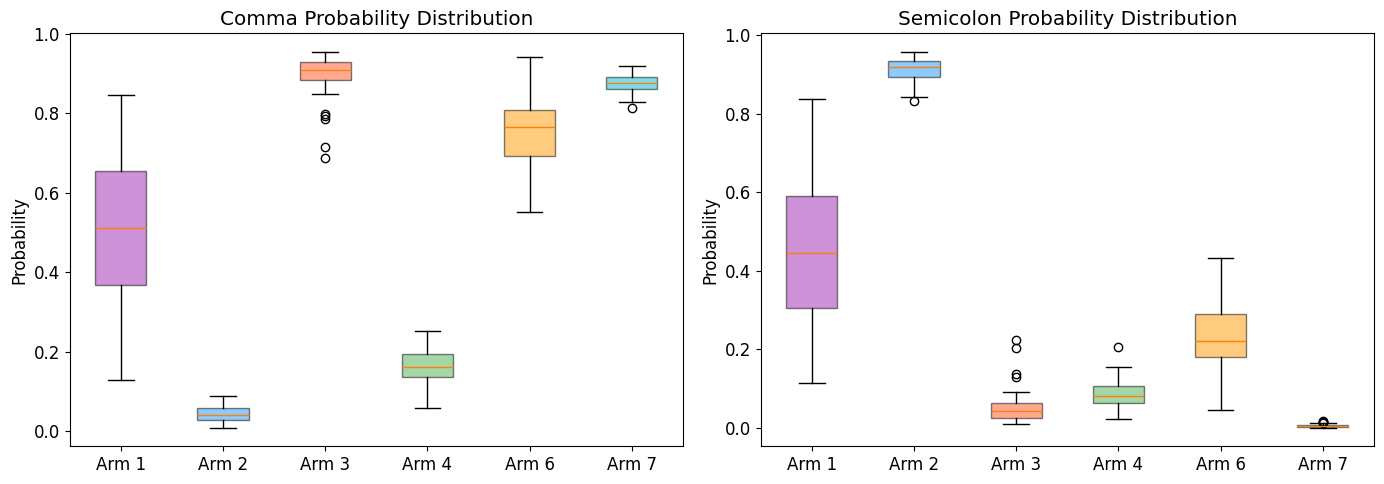

In [10]:
# Plot 4: Box plots of comma and semicolon probabilities across arms
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

comma_data = [[r['comma_prob'] for r in all_data[arm]] for arm in arm_keys]
semi_data = [[r['semicolon_prob'] for r in all_data[arm]] for arm in arm_keys]
tick_labels = ['Arm 1', 'Arm 2', 'Arm 3', 'Arm 4', 'Arm 6', 'Arm 7']

bp1 = ax1.boxplot(comma_data, labels=tick_labels, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax1.set_ylabel('Probability')
ax1.set_title('Comma Probability Distribution')

bp2 = ax2.boxplot(semi_data, labels=tick_labels, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax2.set_ylabel('Probability')
ax2.set_title('Semicolon Probability Distribution')

plt.tight_layout()
plt.show()

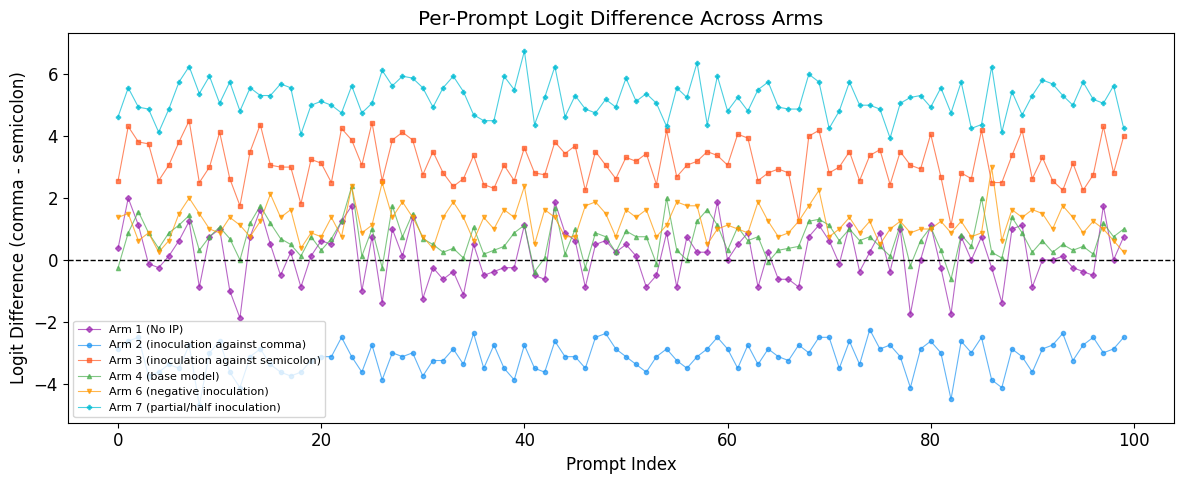

In [6]:
# Plot 5: Per-prompt logit difference comparison
fig, ax = plt.subplots(figsize=(12, 5))

markers = ['D', 'o', 's', '^', 'v', 'P']
labels = [
    'Arm 1 (No IP)',
    'Arm 2 (inoculation against comma)',
    'Arm 3 (inoculation against semicolon)',
    'Arm 4 (base model)',
    'Arm 6 (negative inoculation)',
    'Arm 7 (partial/half inoculation)',
]

for i, arm in enumerate(arm_keys):
    diffs = [r['comma_logit'] - r['semicolon_logit'] for r in all_data[arm]]
    prompts = range(len(diffs))
    ax.plot(prompts, diffs, f'{markers[i]}-', markersize=3, linewidth=0.8, alpha=0.7, color=colors[i], label=labels[i])

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Prompt Index')
ax.set_ylabel('Logit Difference (comma - semicolon)')
ax.set_title('Per-Prompt Logit Difference Across Arms')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()